**Problem 2**

 Load the CIFAR-10 dataset using torchvision.datasets.CIFAR10.  
Apply the following augmentation transforms individually using transforms.Compose, com  
bine all transformed datasets into a single DataLoader, and visualize one image under all   
transformations in a single grid plot.  

Load CIFAR-10 dataset

In [7]:
import torch.nn as nn 

In [5]:
from torchvision.datasets import CIFAR10

In [93]:
from torchvision import transforms 
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [39]:
#  Gaussian Noise: add ϵ ∼ N(0, 0.052) to each pixel and clip to [0,1]
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.052):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Sample noise from N(mean, std^2)
        noise = torch.randn_like(tensor) * self.std + self.mean
        noisy_tensor = tensor + noise
        # Clip to [0,1]
        return torch.clamp(noisy_tensor, 0., 1.)

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"
        
transform_gaussian = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0, 0.052)
])

In [99]:
class AddSaltPepperNoise(object):
    def __init__(self, prob=0.05):
        self.prob = prob

    def __call__(self, tensor):
        # Generate random mask
        rand = torch.rand_like(tensor)
        
        # Pepper (set to 0)
        tensor[rand < (self.prob / 2)] = 0.0
        
        # Salt (set to 1)
        tensor[rand > 1 - (self.prob / 2)] = 1.0
        
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(prob={self.prob})"

transform_salt_and_pepper = transforms.Compose([
    transforms.ToTensor(),
    AddSaltPepperNoise(prob=0.05)
])        

In [66]:
# Rotation: rotate by θ = 30◦ using RandomRotation
transform_rotate_by_theta = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor()
])

In [ ]:
# Horizontal Flip: using RandomHorizontalFlip(p=1.0)
transform_horizontal_flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
])

In [67]:
#  Vertical Flip: using RandomVerticalFlip(p=1.0)
transform_vertical_flip = transforms.Compose([
    transforms.RandomVerticalFlip(p=1.0),
    transforms.ToTensor()
])

In [ ]:
#  Translation: shift by translate=(0.2, 0.15) using RandomAffine
transform_translate = transforms.Compose([
    transforms.RandomAffine(degrees=30, translate=(0.2, 0.15)),
    transforms.ToTensor()
])

In [68]:
# Gaussian Blur: GaussianBlur(kernelsize=3, sigma=1.5)
transform_gaussian_blur = transforms.Compose([
    transforms.GaussianBlur(kernel_size=3, sigma=1.5),
    transforms.ToTensor()
])

In [62]:
#  Random Crop: pad by 4 pixels (reflect mode) then RandomCrop(32)
transform_random_crop = transforms.Compose([
    transforms.Pad(padding=4, padding_mode='reflect'),
    transforms.RandomCrop(32),
    transforms.ToTensor()
])

In [100]:
cifar_train_data = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_gaussian_data = CIFAR10(root='./data', train=True, download=False, transform=transform_gaussian)
cifar_sp_data = CIFAR10(root='./data', train=True, download=False, transform=transform_salt_and_pepper)
cifar_rotbytheta_data = CIFAR10(root='./data', train=True, download=False, transform=transform_rotate_by_theta)
cifar_hflip_data = CIFAR10(root='./data', train=True, download=False, transform=transform_horizontal_flip)
cifar_vflip_data = CIFAR10(root='./data', train=True, download=False, transform=transform_vertical_flip)
cifar_translate_data = CIFAR10(root='./data', train=True, download=False, transform=transform_translate)
cifar_gblur_data = CIFAR10(root='./data', train=True, download=False, transform=transform_gaussian_blur)
cifar_rcrop_data = CIFAR10(root='./data', train=True, download=False, transform=transform_random_crop)

In [101]:
datasets = [
    ("Original", cifar_train_data),
    ("Gaussian", cifar_gaussian_data),
    ("Salt and Pepper", cifar_sp_data),
    ("Rotate by 30", cifar_rotbytheta_data),
    ("Horizontal Flip", cifar_hflip_data),
    ("Vertical Flip", cifar_vflip_data),
    ("Translate", cifar_translate_data),
    ("Gaussian Blur", cifar_gblur_data),
    ("Random Crop", cifar_rcrop_data)
]

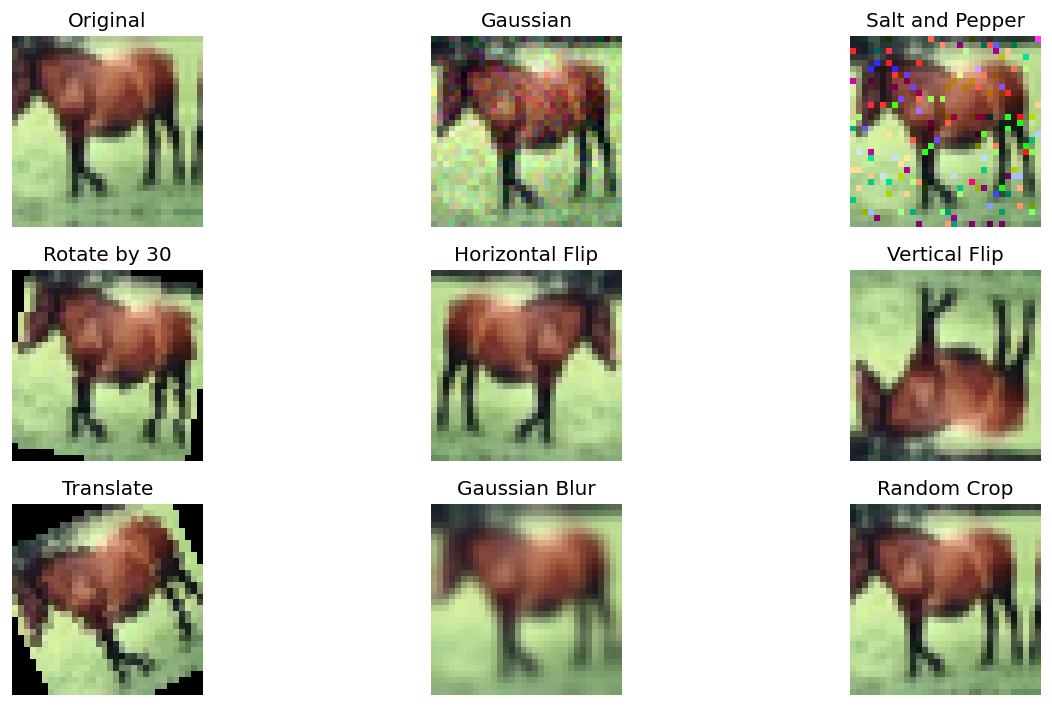

In [102]:
# Visualize one image under all transformations
import matplotlib.pyplot as plt

idx = 7
_, axes = plt.subplots(3,3, figsize=(12, 6), dpi=120)

# For unnormalizing the image
mean=(0.5, 0.5, 0.5)
std=(0.5, 0.5, 0.5)

j = 0
for i, (name, ds) in enumerate(datasets):
    img, label = ds[idx]
    i %= 3
    # print(f"{name} {j} {i}")
    # Unnormalize
    # img = img.clone()
    # for c in range(3):
    #     img[c] = img[c] * std[c] + mean[c]
    # img = torch.clamp(img, 0, 1)

    img = img.permute(1, 2, 0)  # convert to HWC for matplotlib
    # plt.subplot(1, len(datasets), i+1)
    axe = axes[j][i%3]
    axe.imshow(img.numpy(), interpolation="nearest")
    axe.set_title(name)
    axe.axis("off")
    if i==2:
        j += 1

plt.tight_layout()
plt.show()

**Problem 3**

**Bagging Classifier via Maximum Voting on Fashion-MNIST using Pytorch**

**Objective**: Implement a complete bootstrap aggregation (bagging) training and inference  
pipeline to observe how ensembling improves generalization over a single model.     
**Problem Statement**: You will train an ensemble of M = 3 independent Feed-Forward 
Neural Networks on the Fashion-MNIST dataset. To simulate bagging, each network must    
be trained on a unique dataset created by bootstrapping the original training data. Finally,    
you will evaluate the ensemble on a standard, untouched test set using a maximum voting 
scheme. 


In [2]:
# Load the standard Fashion-MNIST dataset (Pytorch: torchvision.datasets.FashionMNIST).
# 60,000 training (80%) + validation images (20%), 10,000 test images.
from torchvision import datasets, transforms

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

fashion_mnist_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_mnist)

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.97MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.32MB/s]


In [3]:
fashion_mnist_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [13]:
from torch import manual_seed
from torch.utils.data import random_split, DataLoader


train_size = int(0.8*len(fashion_mnist_data))
manual_seed(42)
fashion_mnist_train_data, fashion_mnist_validate_data = random_split(fashion_mnist_data, [train_size, len(fashion_mnist_data) - train_size])

In [14]:
fashion_mnist_validate_data

In [15]:
# 4. Load the test set (10,000 images)
fashion_mnist_test_data = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform_mnist
)

In [16]:
fashion_mnist_test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [20]:
# Create three bootstrap version of training data by randomly selecting subsets of images
# from the training split T1,T2,&T3. Each training sets should have randomly chosen
# 38400 image, label pairs.
from torch import randint
from torch.utils.data import Subset

def bootstrap_dataset(dataset, n_samples=38400):
    # Sample indices with replacement
    indices = randint(0, len(dataset), (n_samples,))
    return Subset(dataset, indices)

# Create three bootstrap versions
T1 = bootstrap_dataset(fashion_mnist_train_data, 38400)
T2 = bootstrap_dataset(fashion_mnist_train_data, 38400)
T3 = bootstrap_dataset(fashion_mnist_train_data, 38400)


In [21]:
T1

In [22]:
train_loader_T1 = DataLoader(T1, batch_size=64, shuffle=True)
train_loader_T2   = DataLoader(T2, batch_size=64, shuffle=False)
train_loader_T3  = DataLoader(T3, batch_size=64, shuffle=False)

In [ ]:
# Train three DNN (N1,N2,&N3) using the three training sets T1,T2,&T3
